In [25]:
from google.colab import drive
drive.mount('/content/drive',force_remount = True)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import rasterio

Downlad Mannually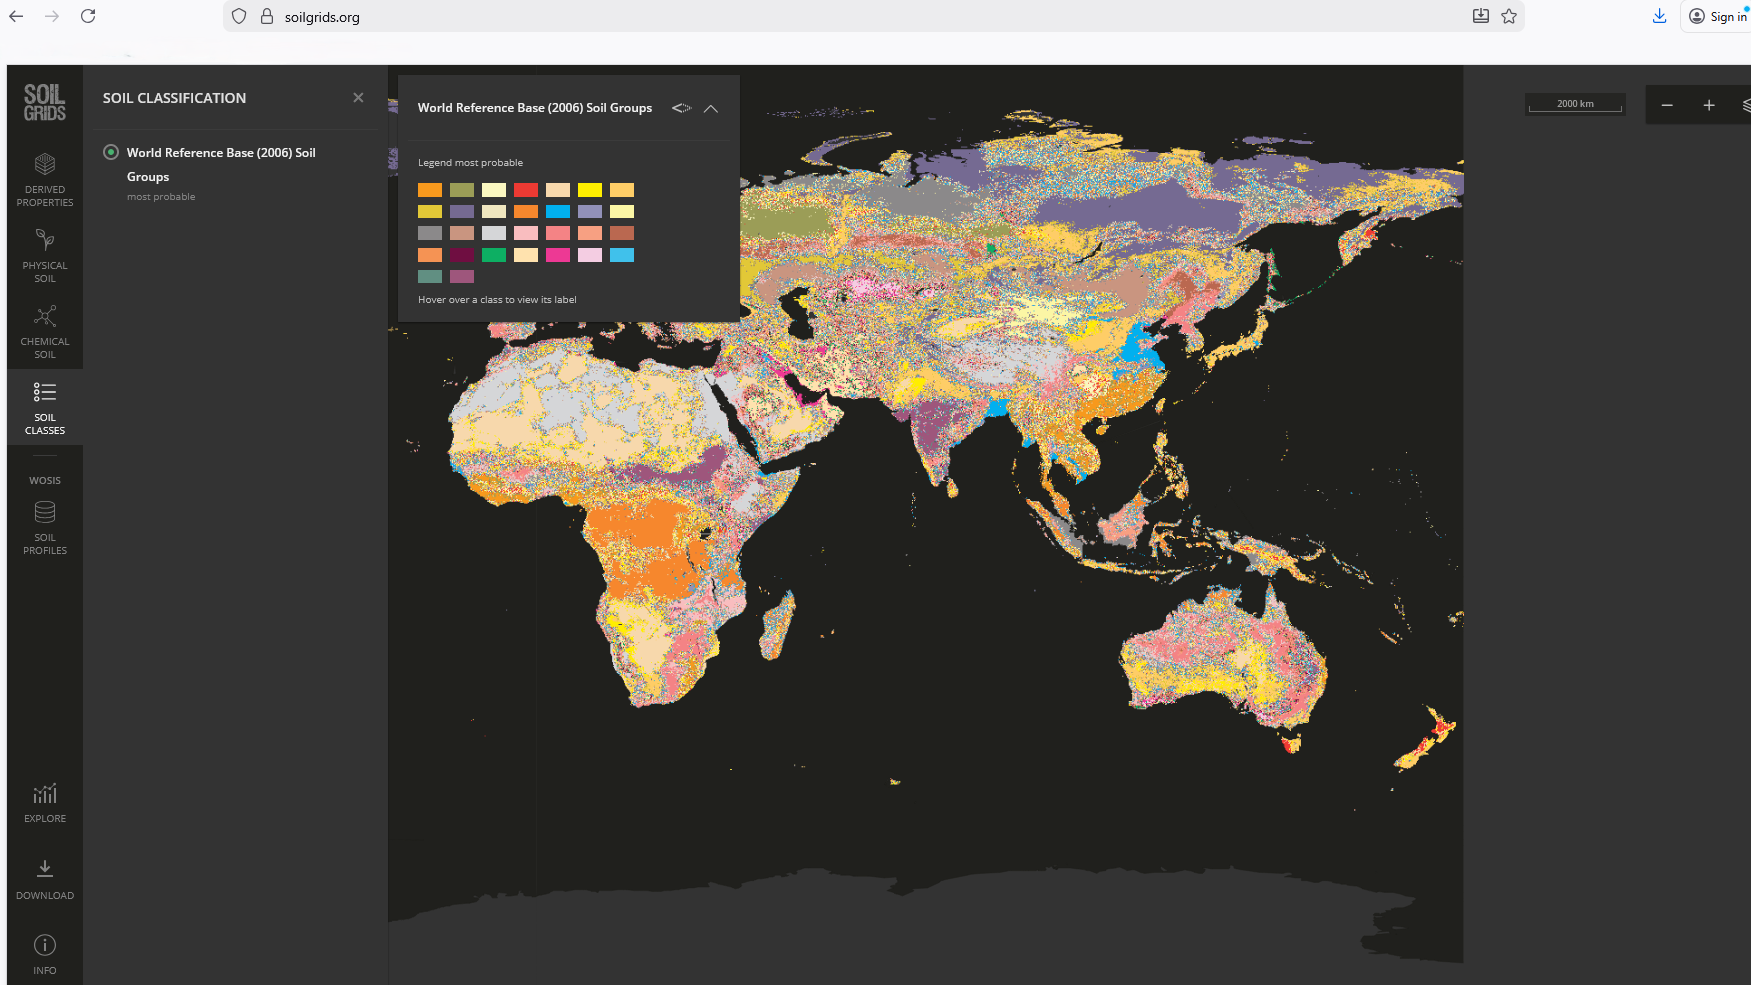

In [27]:
path = '/content/drive/MyDrive/Soil_Data'
data = os.path.join(path, 'UK.tif')

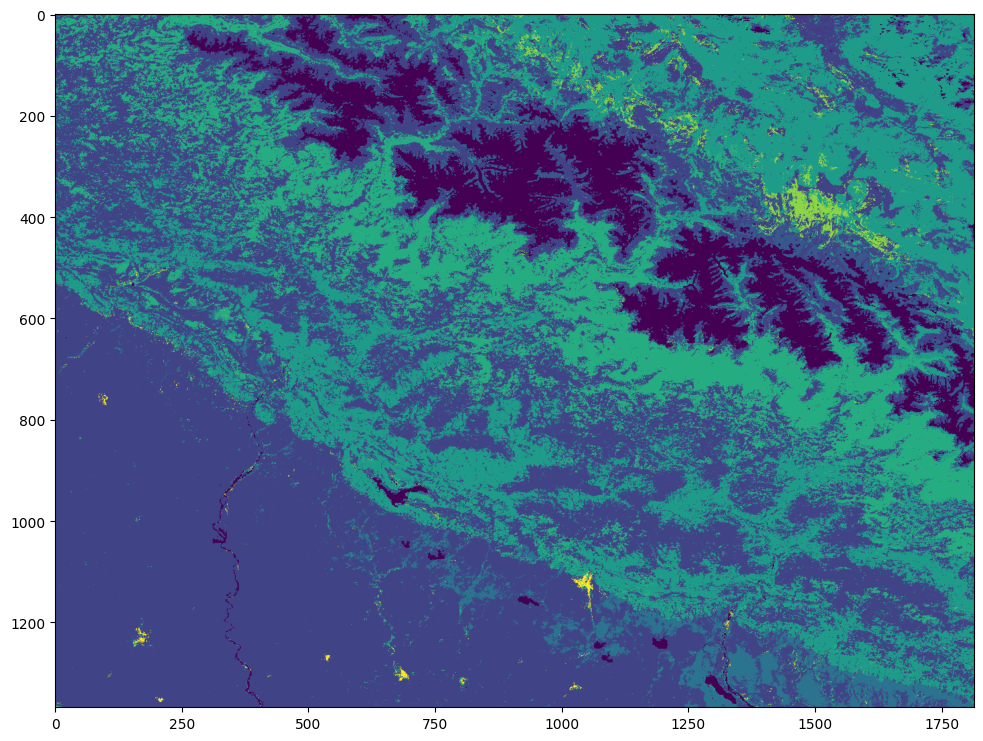

In [28]:
# Open and read the raster
with rasterio.open(data) as src:
    band1 = src.read(1)  # read first band
# Plot the raster
plt.figure(figsize=(16, 9))
plt.imshow(band1, cmap='viridis')
plt.show()

In [22]:
import geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape

with rasterio.open(data) as src:
    band1 = src.read(1)
    mask = band1 != src.nodata

    results = ({"properties": {"soil_type": int(v)}, "geometry": shape(s)}
        for s, v in shapes(band1, mask=mask, transform=src.transform)    )

gdf = gpd.GeoDataFrame.from_features(results, crs=src.crs)
# Save
output = os.path.join(path, "UK_soiltype.gpkg")
gdf.to_file(output, driver="GPKG")
print(f"Vectorized soil types saved as GeoPackage: {output}")

Vectorized soil types saved as GeoPackage: /content/drive/MyDrive/Soil_Data/UK_soiltype.gpkg


For Attribute Table

Source : https://soilwise-he.containers.wur.nl/cat/collections/metadata:main/items/c4dc161c-d62d-11ea-a1a3-292680b15169



In [23]:
# Define the data
soil_data = [[0, "Acrisols"],[1, "Albeluvisols"], [2, "Alisols"], [3, "Andosols"], [4, "Arenosols"], [5, "Calcisols"],
[6, "Cambisols"], [7, "Chernozems"], [8, "Cryosols"], [9, "Durisols"], [10, "Ferralsols"], [11, "Fluvisols"],
[12, "Gleysols"], [13, "Gypsisols"], [14, "Histosols"], [15, "Kastanozems"],  [16, "Leptosols"],  [17, "Lixisols"],
[18, "Luvisols"], [19, "Nitisols"], [20, "Phaeozems"], [21, "Planosols"], [22, "Plinthosols"], [23, "Podzols"],
[24, "Regosols"], [25, "Solonchaks"], [26, "Solonetz"], [27, "Stagnosols"], [28, "Umbrisols"],  [29, "Vertisols"]]

df = pd.DataFrame(soil_data, columns=["Integer", "WRB_Soil_Group"])
df.head()

,Integer,WRB_Soil_Group
0,0,Acrisols
1,1,Albeluvisols
2,2,Alisols
3,3,Andosols
4,4,Arenosols


In [24]:
# Merge GeoDataFrame with soil lookup
gdf = gdf.merge(df, left_on="soil_type", right_on="Integer")
gdf = gdf.drop(columns=["Integer"])

# Save enriched GeoPackage
output = os.path.join(path, "UK_soiltype.gpkg")
gdf.to_file(output, driver="GPKG")
print('Done')

Done
